In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

from ne2001 import density

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
data=pd.read_csv('../../Data/FRB.csv')
data.head()

,FRB,z,DM,DM_ext,gl,gb,From,Ref
0,FRB 20180814A,0.06800,190.900,73.30,136.460000,16.580000,Fan,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,103.396,32.30,133.400000,40.900000,Fan,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,246.000,176.00,130.787670,-41.858020,Fan,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01600,1458.150,1397.15,8.839200,-70.185700,Fan,https://www.cambridge.org/core/journals/public...
4,FRB 20220717A,0.36295,637.340,489.04,19.835158,-17.632032,Fan,https://arxiv.org/pdf/2407.02173


In [3]:
ne = density.ElectronDensity()
cosmo = Planck18
import pygedm

DM, tau_sc = pygedm.dist_to_dm(136.46, 16.58, 100000, method='ne2001')
print(DM, tau_sc)

87.82609558105469 pc / cm3 1.014087106067707e-06 s


/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)


/home/zhuge/miniconda3/lib/python3.10/site-packages/ne2001/density.py:66: RuntimeWarning: overflow encountered in scalar power
  cosh(xyz[-1]/height)**2 *
/home/zhuge/miniconda3/lib/python3.10/site-packages/ne2001/density.py:66: RuntimeWarning: overflow encountered in cosh
  cosh(xyz[-1]/height)**2 *


117.60000000000001


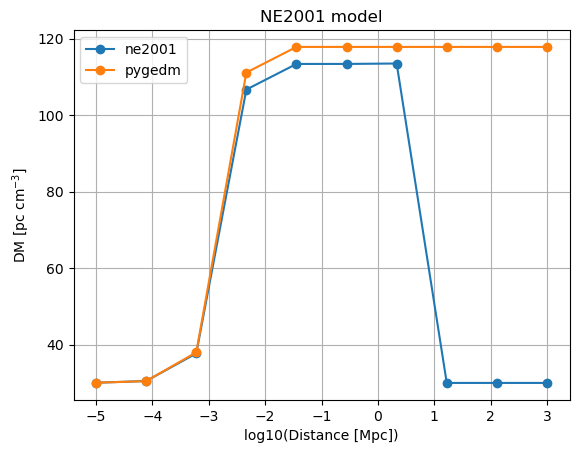

In [4]:
log_test_dis=np.linspace(-5, 3, 10)
test_dis=np.power(10, log_test_dis)

gl=136.46
gb=16.58

DMs=[30+ne.DM(
        l=gl,
        b=gb,
        d= dis* u.Mpc
    ).value for dis in test_dis]
DMs_pygedm=[30+pygedm.dist_to_dm(gl, gb, dis*1e6, method='ne2001')[0].value for dis in test_dis]

print(190.9-73.3)
plt.plot(log_test_dis, DMs, 'o-',label='ne2001')
plt.plot(log_test_dis, DMs_pygedm, 'o-', label='pygedm')
plt.legend()
plt.xlabel('log10(Distance [Mpc])')
plt.ylabel('DM [pc cm$^{-3}$]')
plt.title('NE2001 model')
plt.grid()

In [5]:
print(DMs_pygedm[-1])
print(DMs[-4])

117.82609558105469
113.49060555456217


In [10]:
for idx in range(len(data)):
    # dis=cosmo.comoving_distance(data['z'].iloc[idx])/u.Mpc
    dis=cosmo.luminosity_distance(data['z'].iloc[idx])/u.Mpc
    """ if (dis > 0.1):
        print(dis)
        dis=0.1 """
    data.loc[idx,'DM_ext_ne'] = data.loc[idx,'DM']-30-ne.DM(
        l=data['gl'].iloc[idx],
        b=data['gb'].iloc[idx],
        d=0.1* u.Mpc
    ).value
    data.loc[idx,'DM_ext_pygedm'] = data.loc[idx,'DM']-30-pygedm.dist_to_dm(gl=data['gl'].iloc[idx], 
                            gb=data['gb'].iloc[idx], 
                            dist=dis.value*1e6, 
                            method='ne2001')[0].value

/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)
/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)
/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)
/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)
/home/zhuge/miniconda3/lib/python3.10/site-packages/pygedm/pygedm.py:112: UserWarning: Distance too large, setting to 50 kpc.
  warnings.warn("Distance too large, setting to 50 kpc.", UserWarning)
/home/zhuge/min

In [11]:
data.head()

,FRB,z,DM,DM_ext,gl,gb,From,Ref,DM_ext_ne,DM_ext_pygedm
0,FRB 20180814A,0.06800,190.900,73.30,136.460000,16.580000,Fan,https://www.nature.com/articles/s41586-018-0864-x,77.028630,73.073904
1,FRB 20181030A,0.00385,103.396,32.30,133.400000,40.900000,Fan,https://iopscience.iop.org/article/10.3847/204...,32.907487,33.045498
2,FRB 20220529A,0.18390,246.000,176.00,130.787670,-41.858020,Fan,https://arxiv.org/abs/2503.04727,175.863995,176.048832
3,FRB 20220610A,1.01600,1458.150,1397.15,8.839200,-70.185700,Fan,https://www.cambridge.org/core/journals/public...,1395.787082,1397.192120
4,FRB 20220717A,0.36295,637.340,489.04,19.835158,-17.632032,Fan,https://arxiv.org/pdf/2407.02173,492.333611,489.008396


In [18]:
data.to_csv("./FRB_DM_compare.csv",index=None)

test plot

In [12]:
load_arrays=np.load('./interpolation/068_C0median.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']
sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [13]:
S=0.025
HOf=2.744
e_mu=96.154
sigma_host=0.754

In [15]:
z_range = np.linspace(0.3, 1.5, 500)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

a = 1012.73
b = 113.70
DM_linear = a*z_range+b

DM_theory = np.zeros_like(z_range)

## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 5000, 2000)

target_prob=0.90 # 0.9545 # 0.6827
for idx, z in enumerate(z_range):
    
    """ sigma=sigma_var(np.sqrt(f_variance_delta(F=16, z=z)))
    C0 = C0_sigma(sigma)
    A = A_sigma(sigma)#find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3) """
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0, f_IGM_0 = f_IGM)
    
    ## The range of DM_cosmic (the y-axis)
    # DM_cosmic_range = np.linspace(0.01, np.max(data['DM_ext'])/(DM_theory[idx]), 1000)
    p = [calculate_dm_probability_num_HOf_fast(dm, z=z, 
                                               S=S, HOf=HOf, e_mu=e_mu, sigma_host=sigma_host,
                                               f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
                                               ) 
         for dm in DM_cosmic_range]
    # print(p)
    p = np.array(p)
    index=~np.isnan(p)
    p = p[index]
    p_DM=interpolate.interp1d(DM_cosmic_range[index], p, kind=1,bounds_error=False, 
        # fill_value='extrapolate'
    )
    p=p_DM(DM_cosmic_range)
    # pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    p=normalise(p)
    cdf = np.cumsum(p)
    lower_percentile = 0.5-target_prob/2  # 16%
    upper_percentile = 0.5+target_prob/2  # 84%
    lower_idx = np.searchsorted(cdf, lower_percentile)
    upper_idx = np.searchsorted(cdf, upper_percentile)
    y_low[idx] = DM_cosmic_range[lower_idx]
    y_high[idx] = DM_cosmic_range[upper_idx]

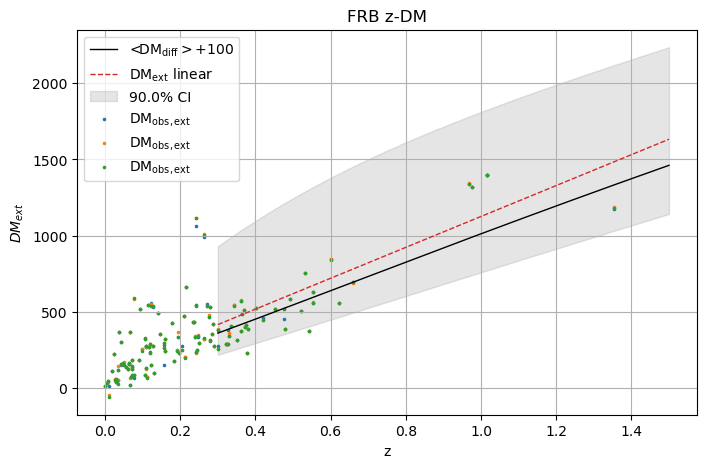

In [17]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

ax1.plot(z_range, 100+DM_theory, lw=1, c='black', label=r'<DM$_{\rm diff}>$+100')
ax1.plot(z_range, DM_linear, lw=1, ls='--', c='tab:red', label=r'DM$_{\rm ext}$ linear')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=f'{100*target_prob}% CI')

ax1.scatter(data['z'], 
            data['DM_ext'], 
            s=10, marker='.', label=r'DM$_{\rm obs, ext}$') 
ax1.scatter(data['z'], 
            data['DM_ext_ne'], 
            s=10, marker='.', label=r'DM$_{\rm obs, ext}$') 
ax1.scatter(data['z'], 
            data['DM_ext_pygedm'], 
            s=10, marker='.', label=r'DM$_{\rm obs, ext}$')  

ax1.set_xlabel('z')
ax1.set_ylabel(r'$DM_{ext}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()

# plt.savefig('./plot/DM_ext_z.pdf', dpi=300, bbox_inches='tight')
plt.show()